In [3]:
# 1. 구글 드라이브 마운트 및 라이브러리 설치
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 라이브러리

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


사진 분석을 시작합니다: /content/drive/MyDrive/SkinAI/YOLO_Dataset_Leak_Free/val/건선/Z4_72003_P0_L0.png

------------------------------
AI 진단 결과
------------------------------
예측된 질환 : 건선
예측 신뢰도 : 100.00%
------------------------------


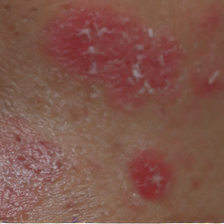

In [ ]:
# 1. 베스트 모델 로드
model_path = '/content/drive/MyDrive/SkinAI/YOLO_Training_Result/skin_disease_model/weights/best.pt'
model = YOLO(model_path)

# 2. 사용자 입력 사진 설정 (지금은 예시)
test_image_path = '/content/drive/MyDrive/SkinAI/YOLO_Dataset_Leak_Free/val/건선/Z4_72003_P0_L0.png'

print(f"사진 분석을 시작합니다: {test_image_path}\n")

# 3. 모델 예측 수행
results = model.predict(source=test_image_path, save=False, verbose=False)

# 4. 분석 결과 추출 및 출력
# 예측 결과 객체에서 첫 번째 결과만 가져오기 (사진을 한 장만 넣었으므로)
result = results[0]

# 가장 확률이 높은(Top-1) 클래스의 인덱스와 신뢰도(확률) 추출
top1_index = result.probs.top1
confidence = result.probs.top1conf.item() * 100 # 퍼센트로 변환

# 인덱스를 통해 실제 질병 이름(문자열) 획득
predicted_disease = result.names[top1_index]

print(f"예측된 질환 : {predicted_disease}")
print(f"예측 신뢰도 : {confidence:.2f}%")

# 5. 사진 시각화 
img = cv2.imread(test_image_path)
if img is not None:
    # 화면에 출력하기 위해 사이즈를 적당히 줄임
    img_resized = cv2.resize(img, (224, 224))
    cv2_imshow(img_resized)
else:
    print("이미지를 불러오지 못했습니다. 경로를 다시 확인해 주세요.")